# KaroSpace Pseudobulk DE Audit

This notebook independently reproduces the current KaroSpace shared-fit pseudobulk DE calculation for one selected category-versus-category contrast.

KaroSpace aggregates raw counts by `replicate` and annotation, retains categories with enough pseudobulk samples, validates the shared `~ replicate + annotation` design, fits one shared `~ _pb_replicate + _pb_group` DESeq2 model, and extracts the selected `source - reference` contrast. Genes below `MIN_PCT_EXPRESSED` in both selected annotations are removed before `DeseqStats`, so they do not enter contrast-level multiple-testing correction.

The same shared fit also provides balanced-rest contrasts in the HTML: one category minus the equally weighted mean of all other retained category coefficients. This audit focuses on one direct category-versus-category contrast.

Pairwise PCA/distance diagnostics are generated for selected category pairs by default. They are based only on the two annotations in the selected pair, using log1p CPM values from the shared-fit pseudobulk count matrix.


In [ ]:
# Parameters: edit this cell
H5AD_PATH = "./data.h5ad"

# Same conceptual inputs as the CLI/API pseudobulk category DE path.
GROUPBY = "Anno_L1_curated"
REPLICATE = "meta_sample_id"
SOURCE = "OPC"  # category shown as positive log2FC / Annotation A
REFERENCE = "Schwann cell"  # baseline category / Annotation B

# Counts and filtering.
COUNTS_LAYER = "counts"  # use None for adata.X
MIN_CELLS = 20  # API: pseudobulk_min_cells_per_sample; CLI: --pseudobulk-min-cells-per-sample
MIN_CELL_COUNTS = 100  # --pseudobulk-min-cell-counts; filters cells by total raw counts before aggregation
MIN_GENE_COUNTS = 100  # --pseudobulk-min-gene-counts; filters genes by total raw pseudobulk counts before fitting
MIN_REPLICATES = 3
MIN_PCT_EXPRESSED = 0.2  # values >1 are interpreted as percentages, e.g. 10 -> 0.10

# DE settings.
P_ADJUST_METHOD = "fdr_bh"  # fdr_bh, bonferroni, holm, none
PADJ_CUTOFF = 0.05  # DE calls use strict padj < cutoff
LOG2FC_CUTOFF = 2
DESEQ2_FIT_TYPE = "mean"  # parametric or mean
N_CPUS = 4


In [2]:
import os
import warnings
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import pdist, squareform

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)

_NUMPY_SLOGDET_WARNING_MESSAGE = r".*encountered in slogdet"
_NUMPY_SLOGDET_PYTHONWARNINGS_FILTERS = (
    "ignore:divide by zero encountered in slogdet:RuntimeWarning",
    "ignore:overflow encountered in slogdet:RuntimeWarning",
    "ignore:invalid value encountered in slogdet:RuntimeWarning",
)


def install_numpy_slogdet_warning_filter():
    warnings.filterwarnings(
        "ignore",
        message=_NUMPY_SLOGDET_WARNING_MESSAGE,
        category=RuntimeWarning,
    )
    existing = os.environ.get("PYTHONWARNINGS", "")
    filters = [part.strip() for part in existing.split(",") if part.strip()]
    changed = False
    for filter_spec in _NUMPY_SLOGDET_PYTHONWARNINGS_FILTERS:
        if filter_spec not in filters:
            filters.append(filter_spec)
            changed = True
    if changed:
        os.environ["PYTHONWARNINGS"] = ",".join(filters)


install_numpy_slogdet_warning_filter()


def normalize_pct_threshold(value):
    threshold = float(value or 0.0)
    if threshold > 1.0:
        threshold /= 100.0
    return min(max(threshold, 0.0), 1.0)


def adjust_pvalues(pvalues, method="fdr_bh"):
    method = str(method or "fdr_bh").strip().lower().replace("-", "_")
    p = np.asarray(pvalues, dtype=float)
    adjusted = np.full(p.shape, np.nan, dtype=float)
    finite = np.isfinite(p)
    if not finite.any():
        return adjusted
    vals = np.clip(p[finite], 0.0, 1.0)
    n = vals.size
    if method in {"none", "raw", "pvalue", "pvalues"}:
        out = vals
    elif method in {"bonferroni", "bonf"}:
        out = np.minimum(vals * n, 1.0)
    elif method in {"holm", "holm_bonferroni"}:
        order = np.argsort(vals)
        ranked = vals[order]
        holm = np.maximum.accumulate((n - np.arange(n)) * ranked)
        holm = np.minimum(holm, 1.0)
        out = np.empty_like(vals)
        out[order] = holm
    else:
        # Benjamini-Hochberg FDR, same logic as KaroSpace pseudobulk.py.
        order = np.argsort(vals)
        ranked = vals[order]
        bh = ranked * n / np.arange(1, n + 1)
        bh = np.minimum.accumulate(bh[::-1])[::-1]
        bh = np.minimum(bh, 1.0)
        out = np.empty_like(vals)
        out[order] = bh
    out[(out == 0) & np.isfinite(out)] = np.nextafter(0.0, 1.0)
    adjusted[finite] = out
    return adjusted


def to_dense_counts(matrix):
    if sp.issparse(matrix):
        matrix = matrix.toarray()
    counts = np.asarray(matrix, dtype=float)
    counts[~np.isfinite(counts)] = 0
    counts[counts < 0] = 0
    return np.rint(counts).astype(int)


def cell_count_mask(matrix, min_cell_counts):
    threshold = max(0, int(min_cell_counts))
    if threshold == 0:
        return np.ones(int(matrix.shape[0]), dtype=bool)
    totals = (
        np.asarray(matrix.sum(axis=1)).ravel()
        if sp.issparse(matrix)
        else np.asarray(matrix).sum(axis=1)
    )
    totals = np.asarray(totals, dtype=float)
    return np.isfinite(totals) & (totals >= threshold)


def filter_pseudobulk_genes(counts, gene_names, min_gene_counts):
    threshold = max(0, int(min_gene_counts))
    if threshold == 0:
        return np.asarray(counts), list(gene_names)
    totals = np.asarray(counts, dtype=float).sum(axis=0)
    keep = np.isfinite(totals) & (totals >= threshold)
    return np.asarray(counts)[:, keep], [
        gene for gene, include in zip(gene_names, keep) if include
    ]


def shared_category_design_rank(metadata):
    replicate = pd.get_dummies(
        metadata["_pb_replicate"].astype(str), drop_first=True, dtype=float
    )
    group = pd.get_dummies(
        metadata["_pb_group"].astype(str), drop_first=True, dtype=float
    )
    design = np.column_stack(
        (np.ones(len(metadata), dtype=float), replicate.to_numpy(), group.to_numpy())
    )
    return int(np.linalg.matrix_rank(design)), int(design.shape[1])


def positive_fraction(matrix, mask, gene_indices):
    gene_indices = np.asarray(gene_indices, dtype=int)
    if not np.any(mask) or gene_indices.size == 0:
        return [np.nan] * gene_indices.size
    sub = matrix[mask][:, gene_indices]
    if sp.issparse(sub):
        counts = np.asarray((sub > 0).sum(axis=0)).ravel()
        return (counts / int(mask.sum())).astype(float)
    return np.mean(np.asarray(sub) > 0, axis=0).astype(float)


def format_p(value):
    value = float(value) if np.isfinite(value) else np.nan
    if not np.isfinite(value):
        return "nan"
    if 0 < value < 0.001:
        return f"{value:.2e}"
    return f"{value:.6g}"


In [3]:
adata = ad.read_h5ad(H5AD_PATH)
print(adata)

required_obs = [GROUPBY, REPLICATE]
missing = [col for col in required_obs if col not in adata.obs.columns]
if missing:
    raise KeyError(f"Missing obs columns: {missing}")

if COUNTS_LAYER and COUNTS_LAYER not in adata.layers:
    warnings.warn(f"COUNTS_LAYER={COUNTS_LAYER!r} not found; falling back to adata.X")
    count_matrix_raw = adata.X
    counts_layer_used = "X"
elif COUNTS_LAYER:
    count_matrix_raw = adata.layers[COUNTS_LAYER]
    counts_layer_used = COUNTS_LAYER
else:
    count_matrix_raw = adata.X
    counts_layer_used = "X"

count_matrix = count_matrix_raw
print(f"Counts source: {counts_layer_used}")
print(f"Genes in AnnData: {adata.n_vars:,}")

AnnData object with n_obs × n_vars = 1384881 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run_id', 'sample_id', 'sample_label', 'xenium_output', 'instrument_or_flowcell', 'cassette_or_slide_id', 'run_date', 'cell_id', 'kmeans_split_id', 'n_counts', 'n_genes', 'leiden_1.5', 'leiden_2', 'leiden_2.5', 'leiden_3', 'leiden_3.5', 'leiden_4.0', 'CellCharter_5', 'CellCharter_10', 'CellCharter_15', 'CellCharter_20', 'CellCharter_25', 'CellCharter_30', 'CellCharter_35', 'CellCharter_40', 'CellCharter_45', 'CellCharter_50', 'meta_sample_id', 'sample_name', 'stage', 'condition', 'day_of_sacrifice', 'score_sacrifice', 'region', 'sex', 'model', 'polygon_label', 'polygon_id', 'polygon_remove', 'polygon_remove_0', 'polygon_remove_1', 'Anno_L1', 'CellCharter_60', 

In [4]:
# Build valid cells and category values exactly like the KaroSpace pseudobulk path.
group_col = adata.obs[GROUPBY]
if pd.api.types.is_numeric_dtype(group_col):
    raise TypeError(
        f"GROUPBY={GROUPBY!r} is numeric; pseudobulk DE expects a categorical annotation"
    )
if not isinstance(group_col.dtype, pd.CategoricalDtype):
    group_col = group_col.astype("category")

categories = [str(cat) for cat in group_col.cat.categories]
print(f"{GROUPBY}: {len(categories)} categories")
print(categories[:30])

if str(SOURCE) not in categories or str(REFERENCE) not in categories:
    raise ValueError(
        f"SOURCE={SOURCE!r} and REFERENCE={REFERENCE!r} must both be in categories"
    )

rep_values = adata.obs[REPLICATE].astype(str)
group_values = group_col.astype(str)
valid = rep_values.notna().to_numpy() & group_values.notna().to_numpy()
valid &= np.asarray(group_col.cat.codes.to_numpy() >= 0, dtype=bool)
valid &= cell_count_mask(count_matrix, MIN_CELL_COUNTS)

valid_indices = np.flatnonzero(valid)
rep_valid = rep_values.iloc[valid_indices].astype(str).to_numpy()
group_valid = group_values.iloc[valid_indices].astype(str).to_numpy()

sample_keys = []
sample_index = {}
rows = np.empty(valid_indices.size, dtype=np.int64)
for i, (rep, grp) in enumerate(zip(rep_valid, group_valid)):
    key = (str(rep), str(grp))
    idx = sample_index.get(key)
    if idx is None:
        idx = len(sample_keys)
        sample_index[key] = idx
        sample_keys.append(key)
    rows[i] = idx

incidence = sp.csr_matrix(
    (np.ones(valid_indices.size, dtype=np.float64), (rows, valid_indices)),
    shape=(len(sample_keys), adata.n_obs),
)
aggregate = to_dense_counts(incidence @ count_matrix)
cell_counts = np.bincount(rows, minlength=len(sample_keys)).astype(int)

pb_meta = pd.DataFrame(
    {
        "_pb_replicate": [key[0] for key in sample_keys],
        "_pb_group": [key[1] for key in sample_keys],
        "n_cells": cell_counts,
    },
    index=[f"pb_{i}" for i in range(len(sample_keys))],
)

display(pb_meta.head())
print(f"Pseudobulk samples: {len(pb_meta):,}")
print(
    f"Aggregate matrix: {aggregate.shape[0]:,} samples x {aggregate.shape[1]:,} genes"
)

Anno_L1_curated: 19 categories
['Astrocyte', 'B cell', 'DC', 'Doublet', 'Endothelial', 'Ependymal cell', 'Epithelial', 'Fibroblast', 'Muscle cell', 'Myeloid', 'NK/DC', 'Neuron', 'Neutrophil', 'OPC', 'Oligodendrocyte', 'Schwann cell', 'T cell', 'T_B_doublet', 'VSMC']


,_pb_replicate,_pb_group,n_cells
pb_0,G3_L1_0,Schwann cell,128
pb_1,G3_L1_0,Astrocyte,1121
pb_2,G3_L1_0,Neuron,1728
pb_3,G3_L1_0,Oligodendrocyte,2460
pb_4,G3_L1_0,Endothelial,833


Pseudobulk samples: 2,541
Aggregate matrix: 2,541 samples x 5,101 genes


In [5]:
# Select the requested source/reference contrast and retain the full shared-fit cohort.
source = str(SOURCE)
reference = str(REFERENCE)
min_cells = int(MIN_CELLS)
min_replicates = max(2, int(MIN_REPLICATES))

sufficient_pb = pb_meta[
    pb_meta["_pb_group"].isin(categories) & (pb_meta["n_cells"] >= min_cells)
]
retained_categories = [
    category
    for category in categories
    if sufficient_pb.loc[
        sufficient_pb["_pb_group"] == category, "_pb_replicate"
    ].nunique()
    >= min_replicates
]
if source not in retained_categories or reference not in retained_categories:
    raise ValueError(f"SOURCE and REFERENCE must be retained: {retained_categories}")

model_mask = pb_meta["_pb_group"].isin(retained_categories) & (
    pb_meta["n_cells"] >= min_cells
)
model_positions = np.flatnonzero(model_mask.to_numpy())
pair_counts = aggregate[model_positions]  # shared-fit count matrix before gene filtering
pair_meta = pb_meta.iloc[model_positions].copy()

design_rank, design_columns = shared_category_design_rank(pair_meta)
residual_df = int(len(pair_meta) - design_rank)
if design_rank < design_columns or residual_df <= 0:
    raise ValueError(
        f"Shared DESeq2 design ~ {REPLICATE} + {GROUPBY} is rank-deficient or has no residual degrees of freedom "
        f"(rank {design_rank}/{design_columns}; residual df {residual_df})."
    )

raw_model_gene_count = int(pair_counts.shape[1])
pair_gene_names = [str(gene) for gene in adata.var_names]
pair_counts, pair_gene_names = filter_pseudobulk_genes(
    pair_counts, pair_gene_names, MIN_GENE_COUNTS
)
if pair_counts.shape[1] == 0:
    raise ValueError(f"No genes meet MIN_GENE_COUNTS={MIN_GENE_COUNTS}")

model_keys = set(
    zip(pair_meta["_pb_replicate"].astype(str), pair_meta["_pb_group"].astype(str))
)
model_cell_mask = valid & np.fromiter(
    (
        (str(rep), str(group)) in model_keys
        for rep, group in zip(rep_values.to_numpy(), group_values.to_numpy())
    ),
    dtype=bool,
    count=adata.n_obs,
)
source_cell_mask = model_cell_mask & (group_values.to_numpy() == source)
reference_cell_mask = model_cell_mask & (group_values.to_numpy() == reference)
n_source = int(source_cell_mask.sum())
n_reference = int(reference_cell_mask.sum())
paired_reps = sorted(
    set(pair_meta.loc[pair_meta["_pb_group"] == source, "_pb_replicate"].astype(str))
    & set(
        pair_meta.loc[pair_meta["_pb_group"] == reference, "_pb_replicate"].astype(str)
    )
)
if len(paired_reps) < min_replicates:
    raise ValueError(
        f"Insufficient paired replicates: {len(paired_reps)}; need >= {min_replicates}"
    )

n_cpus = max(1, int(N_CPUS))
print(
    f"Validated shared design ~ {REPLICATE} + {GROUPBY}: rank {design_rank}/{design_columns}; residual df {residual_df}"
)
print(
    f"Shared-fit cohort: {len(retained_categories)} categories, {pair_counts.shape[0]} pseudobulk samples"
)
print(
    f"Shared-fit gene filter: min_gene_counts={int(MIN_GENE_COUNTS)}; retained {pair_counts.shape[1]:,} of {raw_model_gene_count:,} genes before DESeq2 fitting"
)
print(
    f"Using {n_cpus} CPU worker(s). The numerical results are unchanged by this setting."
)
print(
    f"Reported contrast: {source} vs {reference}; paired replicates: {len(paired_reps)}"
)
display(pair_meta.sort_values(["_pb_replicate", "_pb_group"]).head(20))


Validated shared design ~ meta_sample_id + Anno_L1_curated: rank 173/173; residual df 1869
Shared-fit cohort: 16 categories, 2042 pseudobulk samples
Shared-fit gene filter: min_gene_counts=100; retained 5,101 of 5,101 genes before DESeq2 fitting
Using 4 CPU worker(s). The numerical results are unchanged by this setting.
Reported contrast: OPC vs Schwann cell; paired replicates: 155


,_pb_replicate,_pb_group,n_cells
pb_1699,C2_G1_Bot_0,Astrocyte,1899
pb_1732,C2_G1_Bot_0,B cell,138
pb_1709,C2_G1_Bot_0,DC,594
pb_1733,C2_G1_Bot_0,Doublet,33
pb_1701,C2_G1_Bot_0,Endothelial,1216
pb_1708,C2_G1_Bot_0,Ependymal cell,65
pb_1703,C2_G1_Bot_0,Fibroblast,1098
pb_1704,C2_G1_Bot_0,Myeloid,3847
pb_1710,C2_G1_Bot_0,Neuron,2153
pb_1705,C2_G1_Bot_0,OPC,764


In [6]:
# Fit the shared all-category PyDESeq2 model and extract source minus reference.
import time

counts_df = pd.DataFrame(pair_counts, index=pair_meta.index, columns=pair_gene_names)
meta = pair_meta[["_pb_replicate", "_pb_group"]].copy()
meta["_pb_replicate"] = pd.Categorical(meta["_pb_replicate"].astype(str))
meta["_pb_group"] = pd.Categorical(
    meta["_pb_group"].astype(str), categories=retained_categories
)

print("Design: ~ _pb_replicate + _pb_group")
print(f"Contrast: {source} - {reference} (from the shared all-category fit)")
print(
    f"Fitting {pair_counts.shape[1]:,} genes across {pair_counts.shape[0]:,} pseudobulk samples with {n_cpus} CPU worker(s)…"
)
fit_started = time.perf_counter()
try:
    dds = DeseqDataSet(
        counts=counts_df,
        metadata=meta,
        design="~ _pb_replicate + _pb_group",
        fit_type=DESEQ2_FIT_TYPE,
        n_cpus=n_cpus,
        quiet=True,
    )
except TypeError:
    dds = DeseqDataSet(
        counts=counts_df,
        clinical=meta,
        design_factors=["_pb_replicate", "_pb_group"],
        fit_type=DESEQ2_FIT_TYPE,
        refit_cooks=True,
        n_cpus=n_cpus,
    )
try:
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning)
        dds.deseq2()
except KeyboardInterrupt:
    elapsed = time.perf_counter() - fit_started
    print(
        f"DESeq2 fitting was interrupted after {elapsed / 60:.1f} minutes. Increase N_CPUS if memory permits, then rerun this cell."
    )
    raise
print(
    f"Shared DESeq2 fit completed in {(time.perf_counter() - fit_started) / 60:.1f} minutes."
)

contrast_vector = np.asarray(
    dds.contrast(column="_pb_group", baseline=reference, group_to_compare=source),
    dtype=float,
)

min_pct = normalize_pct_threshold(MIN_PCT_EXPRESSED)
gene_to_idx_all = {str(g): i for i, g in enumerate(adata.var_names)}
valid_pair_genes = [gene for gene in pair_gene_names if gene in gene_to_idx_all]
valid_pair_indices = [gene_to_idx_all[gene] for gene in valid_pair_genes]
min_pct_prefilter_gene_count = len(valid_pair_genes)
if min_pct > 0 and valid_pair_genes:
    fit_pct_source = positive_fraction(
        count_matrix, source_cell_mask, valid_pair_indices
    )
    fit_pct_reference = positive_fraction(
        count_matrix, reference_cell_mask, valid_pair_indices
    )
    test_gene_names = [
        gene
        for gene, source_pct, reference_pct in zip(
            valid_pair_genes, fit_pct_source, fit_pct_reference
        )
        if (0 if pd.isna(source_pct) else float(source_pct)) >= min_pct
        or (0 if pd.isna(reference_pct) else float(reference_pct)) >= min_pct
    ]
else:
    test_gene_names = valid_pair_genes


def subset_fitted_deseq2_dataset(dds_obj, selected_genes):
    selected_genes = [str(gene) for gene in selected_genes]
    if not selected_genes:
        return None
    if (
        len(selected_genes) == int(dds_obj.n_vars)
        and list(map(str, dds_obj.var_names)) == selected_genes
    ):
        return dds_obj
    subset = dds_obj[:, selected_genes].copy()
    try:
        if subset.__class__ is not dds_obj.__class__:
            subset.__class__ = dds_obj.__class__
    except Exception:
        pass
    for attr in (
        "refit_cooks",
        "low_memory",
        "formulaic_contrasts",
        "inference",
        "quiet",
        "fit_type",
        "min_replicates",
        "min_disp",
        "max_disp",
        "beta_tol",
        "min_mu",
        "max_iter",
        "n_cpus",
        "design_factors",
        "ref_level",
        "control_genes",
    ):
        if hasattr(dds_obj, attr):
            try:
                setattr(subset, attr, getattr(dds_obj, attr))
            except Exception:
                pass
    if "non_zero" in subset.var:
        non_zero = subset.var["non_zero"].to_numpy(dtype=bool)
    else:
        non_zero = np.ones(int(subset.n_vars), dtype=bool)
    subset.non_zero_idx = np.arange(int(subset.n_vars))[non_zero]
    subset.non_zero_genes = subset.var_names[non_zero]
    original_new_zeroes = getattr(dds_obj, "new_all_zeroes_genes", pd.Index([]))
    subset_names = {str(gene) for gene in subset.var_names}
    subset.new_all_zeroes_genes = pd.Index(
        [str(gene) for gene in original_new_zeroes if str(gene) in subset_names]
    )
    return subset


min_pct_retained_gene_count = len(test_gene_names)
min_pct_removed_gene_count = max(0, min_pct_prefilter_gene_count - min_pct_retained_gene_count)
print(
    f"Minimum % cells retained {min_pct_retained_gene_count:,} of {min_pct_prefilter_gene_count:,} fitted genes for DeseqStats."
)
print(f"Minimum % cells removed {min_pct_removed_gene_count:,} genes before statistical testing.")
if not test_gene_names:
    raw_results = pd.DataFrame(
        columns=["baseMean", "log2FoldChange", "stat", "pvalue", "padj"]
    )
else:
    dds_for_stats = subset_fitted_deseq2_dataset(dds, test_gene_names)
    try:
        stat_res = DeseqStats(
            dds_for_stats, contrast=contrast_vector, quiet=True, n_cpus=n_cpus
        )
    except TypeError:
        stat_res = DeseqStats(dds_for_stats, contrast=contrast_vector, n_cpus=n_cpus)
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message=_NUMPY_SLOGDET_WARNING_MESSAGE,
            category=RuntimeWarning,
        )
        warnings.filterwarnings("ignore", category=RuntimeWarning)
        stat_res.summary()
    raw_results = stat_res.results_df.copy()

display(raw_results.head())
print(raw_results.shape)

Design: ~ _pb_replicate + _pb_group
Contrast: OPC - Schwann cell (from the shared all-category fit)
Fitting 5,101 genes across 2,042 pseudobulk samples with 4 CPU worker(s)…


/Users/bastien.herve/miniconda3/envs/karospace-pseudobulk/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Shared DESeq2 fit completed in 6.9 minutes.
Minimum % cells retained 1,244 of 5,101 fitted genes for DeseqStats.
Minimum % cells removed 3,857 genes before statistical testing.


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
9630013A20Rik,20.381361,6.578267,0.156428,42.052905,0.000000e+00,0.000000e+00
A2m,317.312396,-0.808032,0.065398,-12.355565,4.545527e-35,6.699806e-35
Abca1,232.388210,-1.594819,0.050948,-31.302732,4.283458e-215,1.168557e-214
Abca3,161.757071,0.025967,0.025232,1.029122,3.034223e-01,3.111767e-01
Abca7,79.534915,0.810710,0.038958,20.809584,3.544072e-96,7.031619e-96


(1244, 6)


In [7]:
# Format and sort exactly like KaroSpace.
# MIN_PCT_EXPRESSED was applied before DeseqStats, so this table contains only
# genes retained for statistical testing in this source-vs-reference contrast.
work = raw_results.copy()
for col in ["baseMean", "log2FoldChange", "stat", "pvalue"]:
    if col not in work.columns:
        work[col] = np.nan

work["padj"] = adjust_pvalues(
    work["pvalue"].to_numpy(dtype=float), method=P_ADJUST_METHOD
)
work["_gene"] = [str(idx) for idx in work.index]

n_before = len(work)
work = work[np.isfinite(work["log2FoldChange"].to_numpy(dtype=float))].copy()
n_finite_log2fc = len(work)

gene_to_idx = {str(g): i for i, g in enumerate(adata.var_names)}
gene_indices = [gene_to_idx.get(g) for g in work["_gene"]]
valid_positions = [i for i, idx in enumerate(gene_indices) if idx is not None]
if len(valid_positions) != len(gene_indices):
    work = work.iloc[valid_positions].copy()
    gene_indices = [gene_indices[i] for i in valid_positions]
n_in_var_names = len(work)

pct_source = positive_fraction(count_matrix, source_cell_mask, gene_indices)
pct_reference = positive_fraction(count_matrix, reference_cell_mask, gene_indices)
work["pct_source"] = pct_source
work["pct_reference"] = pct_reference

min_pct = normalize_pct_threshold(MIN_PCT_EXPRESSED)

work["_padj_sort"] = work["padj"].fillna(np.inf)
work["_pvalue_sort"] = work["pvalue"].fillna(np.inf)
work["_abs_lfc"] = np.abs(work["log2FoldChange"].to_numpy(dtype=float))
work = work.sort_values(
    ["_padj_sort", "_pvalue_sort", "_abs_lfc", "_gene"],
    ascending=[True, True, False, True],
)

de_table = (
    work[
        [
            "_gene",
            "baseMean",
            "log2FoldChange",
            "pvalue",
            "padj",
            "stat",
            "pct_source",
            "pct_reference",
        ]
    ]
    .rename(
        columns={
            "_gene": "gene",
            "log2FoldChange": "log2fc",
            "stat": "score",
        }
    )
    .reset_index(drop=True)
)

print("Formatting audit")
print(f"  DeseqStats rows:          {n_before:,}")
print(f"  finite log2FC:            {n_finite_log2fc:,}")
print(f"  matched adata.var_names:  {n_in_var_names:,}")
print(f"  min pct prefilter:        {min_pct:.3f}")
print(f"  min pct removed genes:    {min_pct_removed_gene_count:,}")
print(f"  ranked/exported genes:    {len(de_table):,}")

display(de_table.head(30))

Formatting audit
  DeseqStats rows:          1,244
  finite log2FC:            1,244
  matched adata.var_names:  1,244
  min pct prefilter:        0.200
  min pct removed genes:    3,857
  ranked/exported genes:    1,244


,gene,baseMean,log2fc,pvalue,padj,score,pct_source,pct_reference
0,Ogn,128.884982,-10.540800,0.0,4.940656e-324,-66.465569,0.002522,0.543135
1,Sostdc1,39.102417,-9.195957,0.0,4.940656e-324,-53.144833,0.002610,0.347916
2,Gldn,89.231548,-8.608023,0.0,4.940656e-324,-71.576704,0.009936,0.520728
3,Gpr17,143.636317,8.468806,0.0,4.940656e-324,78.085843,0.808975,0.007243
4,Tnr,247.346984,8.217038,0.0,4.940656e-324,94.838507,0.960014,0.011689
5,Cdh1,55.282640,-8.192254,0.0,4.940656e-324,-52.351568,0.004584,0.347450
6,Mfap5,76.669954,-8.072409,0.0,4.940656e-324,-74.043106,0.008028,0.414536
7,Lamb1,43.831161,-7.899101,0.0,4.940656e-324,-73.347553,0.005769,0.389255
8,Myt1,65.990233,7.814341,0.0,4.940656e-324,70.042828,0.677700,0.004641
9,Egr2,31.063473,-7.747306,0.0,4.940656e-324,-59.430167,0.005396,0.297761


In [8]:
# Threshold summaries matching the viewer logic.
padj_cutoff = float(PADJ_CUTOFF)
log2fc_cutoff = float(LOG2FC_CUTOFF)
ma_padj_cutoff = 0.1
stats_pass = (de_table["padj"] < padj_cutoff) & (
    de_table["log2fc"].abs() >= log2fc_cutoff
)
volcano_pass = stats_pass
ma_padj_pass = de_table["padj"] < ma_padj_cutoff
ma_pass = ma_padj_pass

print(
    f"MA red genes, adj. p < {ma_padj_cutoff}: {int(ma_pass.sum()):,} / {len(de_table):,}"
)
print(f"  grey, adj. p >= {ma_padj_cutoff}: {int((~ma_padj_pass).sum()):,}")
print(
    "Volcano/table passing genes, "
    f"padj < {padj_cutoff}, |log2FC| >= {log2fc_cutoff}: {int(volcano_pass.sum()):,} / {len(de_table):,}"
)
print(
    f"  positive/source-colored: {int((volcano_pass & (de_table['log2fc'] > 0)).sum()):,}"
)
print(
    f"  negative/reference-colored: {int((volcano_pass & (de_table['log2fc'] < 0)).sum()):,}"
)

display(de_table.loc[volcano_pass].head(50))

MA red genes, adj. p < 0.1: 1,180 / 1,244
  grey, adj. p >= 0.1: 64
Volcano/table passing genes, padj < 0.05, |log2FC| >= 2.0: 278 / 1,244
  positive/source-colored: 166
  negative/reference-colored: 112


,gene,baseMean,log2fc,pvalue,padj,score,pct_source,pct_reference
0,Ogn,128.884982,-10.540800,0.0,4.940656e-324,-66.465569,0.002522,0.543135
1,Sostdc1,39.102417,-9.195957,0.0,4.940656e-324,-53.144833,0.002610,0.347916
2,Gldn,89.231548,-8.608023,0.0,4.940656e-324,-71.576704,0.009936,0.520728
3,Gpr17,143.636317,8.468806,0.0,4.940656e-324,78.085843,0.808975,0.007243
4,Tnr,247.346984,8.217038,0.0,4.940656e-324,94.838507,0.960014,0.011689
...,...,...,...,...,...,...,...,...
45,Mme,32.984832,-5.443738,0.0,4.940656e-324,-66.559937,0.019192,0.307237
46,Slitrk3,16.595139,5.330507,0.0,4.940656e-324,43.059712,0.213661,0.002990
47,Col5a1,57.818121,-5.328235,0.0,4.940656e-324,-70.899561,0.026189,0.323450
48,Kcnip3,109.615216,5.246557,0.0,4.940656e-324,86.398285,0.577746,0.024155


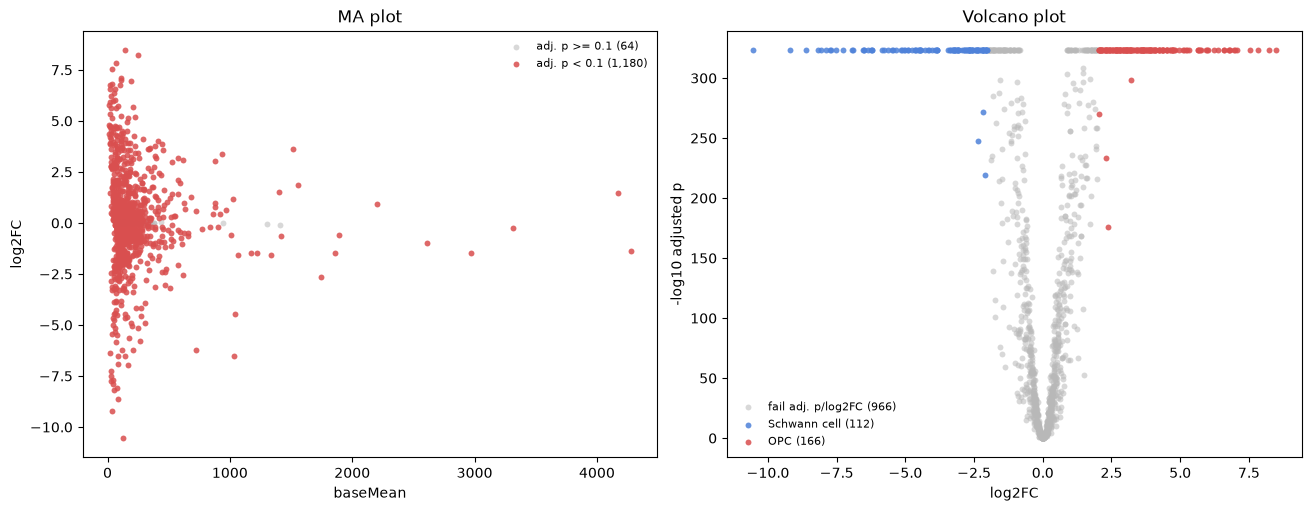

In [9]:
# MA and volcano plots matching the viewer dot classes.
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

ax = axes[0]
ma_layers = [
    (~ma_padj_pass, "#b8b8b8", f"adj. p >= 0.1 ({int((~ma_padj_pass).sum()):,})", 0.55),
    (ma_pass, "#d94f4f", f"adj. p < 0.1 ({int(ma_pass.sum()):,})", 0.86),
]
for mask, color, label, alpha in ma_layers:
    if not mask.any():
        continue
    ax.scatter(
        de_table.loc[mask, "baseMean"],
        de_table.loc[mask, "log2fc"],
        c=color,
        s=18,
        alpha=alpha,
        linewidths=0,
        label=label,
    )
ax.set_xlabel("baseMean")
ax.set_ylabel("log2FC")
ax.set_title("MA plot")
ax.legend(frameon=False, fontsize=8, loc="best")
ax.grid(False)

ax = axes[1]
source_pass = volcano_pass & (de_table["log2fc"] > 0)
reference_pass = volcano_pass & (de_table["log2fc"] < 0)
volcano_layers = [
    (
        ~stats_pass,
        "#b8b8b8",
        f"fail adj. p/log2FC ({int((~stats_pass).sum()):,})",
        0.55,
    ),
    (reference_pass, "#4f82d9", f"{reference} ({int(reference_pass.sum()):,})", 0.86),
    (source_pass, "#d94f4f", f"{source} ({int(source_pass.sum()):,})", 0.86),
]
safe_padj = de_table["padj"].fillna(1).clip(lower=np.nextafter(0.0, 1.0))
neg_log10_padj = -np.log10(safe_padj)
for mask, color, label, alpha in volcano_layers:
    if not mask.any():
        continue
    ax.scatter(
        de_table.loc[mask, "log2fc"],
        neg_log10_padj.loc[mask],
        c=color,
        s=18,
        alpha=alpha,
        linewidths=0,
        label=label,
    )
ax.set_xlabel("log2FC")
ax.set_ylabel("-log10 adjusted p")
ax.set_title("Volcano plot")
ax.legend(frameon=False, fontsize=8, loc="best")

plt.show()

Pairwise diagnostic: OPC vs Schwann cell; 313 pseudobulk samples; 5101 variable genes


,_pb_replicate,_pb_group,n_cells,library_size,PC1,PC2
pb_0,G3_L1_0,Schwann cell,128,85473,-42.310774,12.731446
pb_6,G3_L1_2,Schwann cell,1376,740918,-44.465563,-15.295286
pb_16,G3_L1_1,Schwann cell,937,678099,-45.563238,-20.386399
pb_21,G3_L1_1,OPC,406,615939,41.608207,-21.077567
pb_25,G3_L1_0,OPC,214,278496,52.045442,14.961410
pb_41,G3_L1_2,OPC,246,226694,47.960577,-4.866254
pb_53,G3_L2_1,OPC,227,271443,48.075609,-5.925667
pb_61,G3_L2_2,OPC,553,741080,39.750473,-16.217265
pb_73,G3_L2_1,Schwann cell,771,527591,-43.229759,-21.322697
pb_79,G3_L2_0,OPC,150,175808,53.094571,19.040454


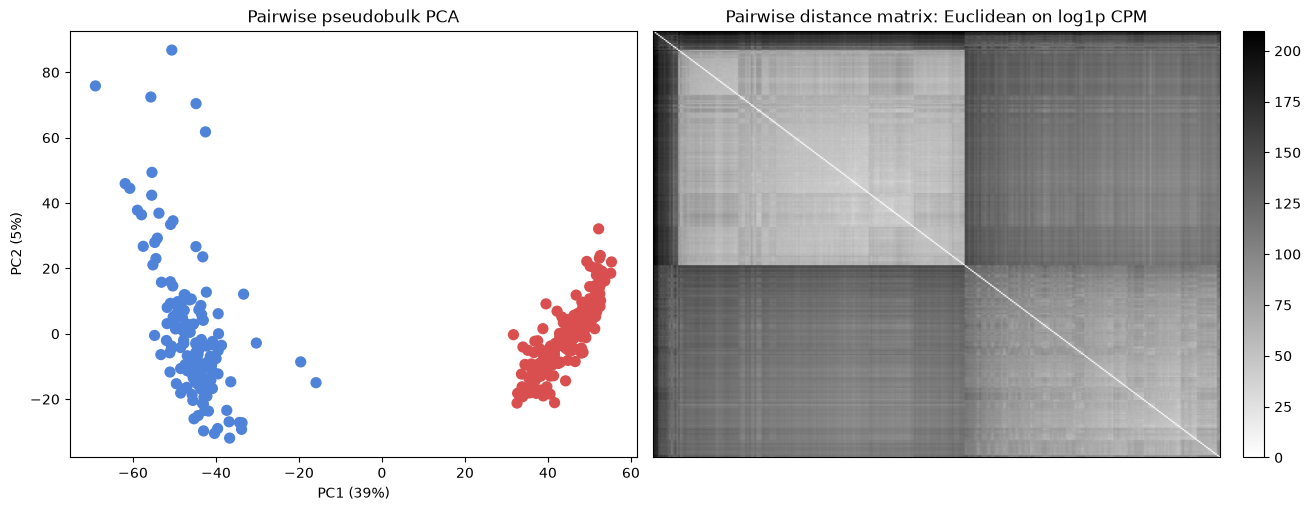

In [10]:
# Pairwise PCA and distance matrix diagnostics matching KaroSpace's log1p CPM preprocessing.
# KaroSpace stores pair diagnostics only for the selected source/reference pair, not the full category matrix.
diag_positions = np.flatnonzero(pair_meta["_pb_group"].isin([source, reference]).to_numpy())
diag_meta = pair_meta.iloc[diag_positions].copy()
counts = np.array(pair_counts[diag_positions], dtype=float, copy=True)
counts[~np.isfinite(counts)] = 0
counts[counts < 0] = 0
library_sizes = counts.sum(axis=1)
safe_libs = np.where(library_sizes > 0, library_sizes, 1.0)
log_cpm = np.log1p((counts / safe_libs[:, None]) * 1_000_000.0)

variances = np.var(log_cpm, axis=0)
finite_var = np.isfinite(variances) & (variances > 0)
feature_idx = (
    np.flatnonzero(finite_var) if finite_var.any() else np.arange(log_cpm.shape[1])
)

diag_matrix = log_cpm[:, feature_idx]
diag_matrix = diag_matrix - np.nanmean(diag_matrix, axis=0, keepdims=True)
diag_matrix[~np.isfinite(diag_matrix)] = 0

try:
    u, s, vt = np.linalg.svd(diag_matrix, full_matrices=False)
    scores = u[:, :2] * s[:2]
    if scores.shape[1] == 1:
        scores = np.column_stack([scores[:, 0], np.zeros(scores.shape[0])])
    eig = s**2
    var_explained = eig / eig.sum() if eig.sum() > 0 else np.array([np.nan, np.nan])
except Exception:
    scores = np.zeros((counts.shape[0], 2), dtype=float)
    var_explained = np.array([np.nan, np.nan])

try:
    condensed = pdist(diag_matrix, metric="euclidean")
    dist = squareform(condensed)
    leaf_order = (
        leaves_list(linkage(condensed, method="average")).astype(int).tolist()
        if condensed.size
        else list(range(counts.shape[0]))
    )
except Exception:
    diff = diag_matrix[:, None, :] - diag_matrix[None, :, :]
    dist = np.sqrt(np.sum(diff * diff, axis=2))
    leaf_order = list(range(counts.shape[0]))
ordered_dist = dist[np.ix_(leaf_order, leaf_order)]

diag_info = diag_meta.copy()
diag_info["library_size"] = library_sizes.astype(int)
diag_info["PC1"] = scores[:, 0]
diag_info["PC2"] = scores[:, 1]
print(
    f"Pairwise diagnostic: {source} vs {reference}; {counts.shape[0]} pseudobulk samples; {feature_idx.size} variable genes"
)
display(diag_info.head(20))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
group_color = {source: "#d94f4f", reference: "#4f82d9"}
point_colors = [group_color.get(g, "#999999") for g in diag_meta["_pb_group"]]

axes[0].scatter(scores[:, 0], scores[:, 1], c=point_colors, s=50)
axes[0].set_xlabel(
    f"PC1 ({var_explained[0] * 100:.0f}%)" if np.isfinite(var_explained[0]) else "PC1"
)
axes[0].set_ylabel(
    f"PC2 ({var_explained[1] * 100:.0f}%)"
    if len(var_explained) > 1 and np.isfinite(var_explained[1])
    else "PC2"
)
axes[0].set_title("Pairwise pseudobulk PCA")

im = axes[1].imshow(ordered_dist, cmap="gray_r", aspect="auto")
axes[1].set_title("Pairwise distance matrix: Euclidean on log1p CPM")
axes[1].set_xticks([])
axes[1].set_yticks([])
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.show()


In [ ]:
# Save the audited result table.
# out_csv = Path(H5AD_PATH).with_suffix(f".{GROUPBY}.{source}_vs_{reference}.pseudobulk_audit.csv")
# de_table.to_csv(out_csv, index=False)
# print(out_csv)

## Pathway Enrichment Audit: ORA and Preranked GSEA

This section mirrors the KaroSpace viewer pathway summaries added after Simple design pseudobulk DE. It runs over the formatted `de_table` for the selected `source - reference` contrast.

- ORA is run separately on significant positive and negative DE genes. `MIN_PCT_EXPRESSED` is applied before `DeseqStats`; ORA then uses genes passing `padj < PADJ_CUTOFF` and `|log2FC| >= LOG2FC_CUTOFF`. The dot plot x-axis is `GeneRatio` (`overlap / query_size`), dot size is the number of overlapping genes, fill color is `-log10 adjusted p-value`, and dot border is red for `padj < 0.05` or black for `padj >= 0.05`.
- GSEA uses the full ranked gene list retained after model-level and `% expressed` filtering, not only the significant DE genes. The notebook shows the same enrichment-profile style plot as the viewer for retained positive and negative pathways: running ES curve, pathway hit ticks, and ranked metric scores.
- Set `PATHWAY_GMT` to one or more local `.gmt` files for fully offline/reproducible runs. Leave it as `None` to use Reactome through GSEApy, matching the viewer default when `--pathway-gmt` is omitted.


In [11]:
# Pathway enrichment settings: edit this cell if needed.
PATHWAY_GMT = None  # None uses Reactome via GSEApy; or use "reactome.gmt" / ["reactome.gmt", "go_bp.gmt"]
PATHWAY_ORGANISM = "Mouse"
PATHWAY_TOP_N = 20
PATHWAY_MIN_OVERLAP = 3
PATHWAY_MAX_SIZE = 500
PATHWAY_GSEA_PERMUTATIONS = 100  # use 0 for faster ES/NES-only audit
PATHWAY_GSEA_SEED = 0  # KaroSpace uses seed + comparison index; this notebook adds +1 below

In [12]:
# Compute ORA and compact preranked GSEA from the audited DE table.
import sys

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import importlib
import karospace.pathways as pathway_module

# In notebooks, reload this module so rerunning the cell picks up local KaroSpace edits
# without requiring a kernel restart.
pathway_module = importlib.reload(pathway_module)
enrich_pseudobulk_result = pathway_module.enrich_pseudobulk_result
load_pathway_gene_sets = pathway_module.load_pathway_gene_sets

if de_table.empty:
    raise ValueError(
        "de_table is empty; run the DE cells above before pathway enrichment."
    )

pathway_result = {
    "available": True,
    "genes": de_table["gene"].astype(str).tolist(),
    "base_mean": de_table["baseMean"].astype(float).tolist(),
    "log2foldchanges": de_table["log2fc"].astype(float).tolist(),
    "pvals": de_table["pvalue"].astype(float).tolist(),
    "pvals_adj": de_table["padj"].astype(float).tolist(),
    "scores": de_table["score"].astype(float).tolist(),
    "pct_source": de_table["pct_source"].astype(float).tolist(),
    "pct_reference": de_table["pct_reference"].astype(float).tolist(),
    "min_pct_expressed": float(min_pct),
    "padj_cutoff": float(padj_cutoff),
    "log2fc_cutoff": float(log2fc_cutoff),
}

try:
    pathway_gene_sets, pathway_source = load_pathway_gene_sets(
        PATHWAY_GMT,
        organism=PATHWAY_ORGANISM,
    )
except Exception as exc:
    pathway_gene_sets = None
    pathway_source = {
        "available": False,
        "error": str(exc),
    }
    print("Could not load pathway gene sets:")
    print(exc)
    print()
    print(
        "For an offline run, set PATHWAY_GMT to a local Reactome/MSigDB/WikiPathways GMT file and rerun this cell."
    )

if pathway_gene_sets:
    pathway_enrichment = enrich_pseudobulk_result(
        pathway_result,
        pathway_gene_sets,
        top_n=int(PATHWAY_TOP_N),
        min_overlap=int(PATHWAY_MIN_OVERLAP),
        max_pathway_size=int(PATHWAY_MAX_SIZE),
        gsea_permutations=int(PATHWAY_GSEA_PERMUTATIONS),
        seed=int(PATHWAY_GSEA_SEED) + 1,
    )
else:
    pathway_enrichment = None

print("Pathway source")
display(pd.DataFrame([pathway_source]))

if not pathway_enrichment:
    print("No pathway enrichment results were produced for this contrast.")
else:
    print(
        f"Tested pathways: {pathway_enrichment['tested_pathways']:,}; "
        f"GSEA ranked universe: {pathway_enrichment['universe_size']:,} genes"
    )

Pathway source


,source,library,organism,gene_set_count
0,reactome,Reactome_Pathways_2024,Mouse,2100


Tested pathways: 1,211; GSEA ranked universe: 1,244 genes


In [13]:
# Display compact ORA and GSEA result tables while keeping full rows for plotting.
def pathway_rows_df(method, direction):
    rows = (
        []
        if pathway_enrichment is None
        else pathway_enrichment.get(method, {}).get(direction, [])
    )
    return pd.DataFrame(rows)


def pathway_table(df):
    if df is None or df.empty:
        return df
    cols = [
        col
        for col in [
            "term",
            "direction",
            "padj",
            "pval",
            "odds_ratio",
            "nes",
            "es",
            "overlap",
            "query_size",
            "pathway_size",
            "rank_count",
            "peak_rank",
            "zero_cross_rank",
            "genes",
            "leading_edge",
        ]
        if col in df.columns
    ]
    return df[cols]


ora_up = pathway_rows_df("ora", "up")
ora_down = pathway_rows_df("ora", "down")
gsea_positive = pathway_rows_df("gsea", "positive")
gsea_negative = pathway_rows_df("gsea", "negative")

ora_up_table = pathway_table(ora_up)
ora_down_table = pathway_table(ora_down)
gsea_positive_table = pathway_table(gsea_positive)
gsea_negative_table = pathway_table(gsea_negative)

print(f"ORA up pathways favoring {source}")
display(ora_up_table.head(int(PATHWAY_TOP_N)))
print(f"ORA down pathways favoring {reference}")
display(ora_down_table.head(int(PATHWAY_TOP_N)))
print(f"GSEA positive enrichment pathways favoring {source}")
display(gsea_positive_table.head(int(PATHWAY_TOP_N)))
print(f"GSEA negative enrichment pathways favoring {reference}")
display(gsea_negative_table.head(int(PATHWAY_TOP_N)))

for name, df in {
    "gsea_positive": gsea_positive,
    "gsea_negative": gsea_negative,
}.items():
    missing = {"running_profile", "hit_indices", "rank_metric_profile"}.difference(
        df.columns if df is not None else []
    )
    if df is not None and not df.empty and missing:
        print(
            f"Warning: {name} is missing {sorted(missing)}. "
            "Rerun the pathway computation cell above, or restart the kernel if an old KaroSpace module was cached."
        )

ORA up pathways favoring OPC


,term,direction,padj,pval,odds_ratio,overlap,query_size,pathway_size,genes
0,Neuronal System,up,0.000313,0.000003,3.817582,24,166,70,"[Epb41l1, Erbb4, Gabrb3, Glra1, Gria2, Gria4, ..."
1,Transmission Across Chemical Synapses,up,0.004433,0.000253,3.343336,17,166,53,"[Epb41l1, Erbb4, Gabrb3, Glra1, Gria2, Gria4, ..."
2,Chondroitin Sulfate Biosynthesis,up,0.004433,0.000307,59.732308,4,166,4,"[Cspg4, Cspg5, Ncan, Vcan]"
3,"Defective CHST14 Causes EDS, Musculocontractur...",up,0.004433,0.000307,59.732308,4,166,4,"[Cspg4, Cspg5, Ncan, Vcan]"
4,Defective CHST3 Causes SEDCJD,up,0.004433,0.000307,59.732308,4,166,4,"[Cspg4, Cspg5, Ncan, Vcan]"
5,Defective CHSY1 Causes TPBS,up,0.004433,0.000307,59.732308,4,166,4,"[Cspg4, Cspg5, Ncan, Vcan]"
6,Dermatan Sulfate Biosynthesis,up,0.004433,0.000307,59.732308,4,166,4,"[Cspg4, Cspg5, Ncan, Vcan]"
7,Sensory Processing of Sound,up,0.026672,0.002652,5.293681,7,166,16,"[Atp2b2, Cabp1, Epb41l1, Pcdh15, Snap25, Syn1,..."
8,Sensory Processing of Sound by Inner Hair Cell...,up,0.026672,0.002652,5.293681,7,166,16,"[Atp2b2, Cabp1, Epb41l1, Pcdh15, Snap25, Syn1,..."
9,A Tetrasaccharide Linker Sequence Is Required ...,up,0.026672,0.003697,11.924308,4,166,6,"[Cspg4, Cspg5, Ncan, Vcan]"


ORA down pathways favoring Schwann cell


,term,direction,padj,pval,odds_ratio,overlap,query_size,pathway_size,genes
0,Extracellular Matrix Organization,down,0.000000,0.000000,10.427119,28,112,63,"[Adam10, Adamts5, Cd151, Cdh1, Col14a1, Col15a..."
1,Laminin Interactions,down,0.000000,0.000000,43.785355,13,112,16,"[Col18a1, Col4a1, Col4a2, Hspg2, Itga6, Itga7,..."
2,Non-integrin membrane-ECM Interactions,down,0.000000,0.000000,20.360804,13,112,20,"[Col1a1, Col1a2, Col4a1, Col4a2, Col5a1, Dag1,..."
3,Assembly of Collagen Fibrils and Other Multime...,down,0.000000,0.000000,25.497512,12,112,17,"[Cd151, Col14a1, Col15a1, Col18a1, Col1a1, Col..."
4,Degradation of the Extracellular Matrix,down,0.000000,0.000000,12.262953,15,112,29,"[Adam10, Adamts5, Cdh1, Col14a1, Col15a1, Col1..."
5,Collagen Formation,down,0.000000,0.000000,16.045755,13,112,22,"[Cd151, Col14a1, Col15a1, Col18a1, Col1a1, Col..."
6,ECM Proteoglycans,down,0.000000,0.000000,13.195736,14,112,26,"[Col1a1, Col1a2, Col4a1, Col4a2, Col5a1, Dag1,..."
7,Collagen Chain Trimerization,down,0.000000,0.000000,41.506280,9,112,11,"[Col14a1, Col15a1, Col18a1, Col1a1, Col1a2, Co..."
8,Collagen Degradation,down,0.000001,0.000000,21.000000,10,112,15,"[Adam10, Col14a1, Col15a1, Col18a1, Col1a1, Co..."
9,Integrin Cell Surface Interactions,down,0.000001,0.000000,12.129570,12,112,23,"[Cdh1, Col18a1, Col1a1, Col1a2, Col23a1, Col4a..."


GSEA positive enrichment pathways favoring OPC


,term,direction,padj,pval,nes,es,overlap,pathway_size,rank_count,peak_rank,zero_cross_rank,leading_edge
0,Neuronal System,positive,0.210353,0.009901,1.947042,0.496480,70,70,1244,214,656,"[Gria4, Mapt, Ppfibp1, Nlgn3, Slc1a1, Gria2, E..."
1,Transmission Across Chemical Synapses,positive,0.210353,0.009901,1.897711,0.483355,53,53,1244,214,656,"[Gria4, Mapt, Slc1a1, Gria2, Epb41l1, Syn2, Sl..."
2,Neurotransmitter Release Cycle,positive,0.210353,0.009901,1.812031,0.739797,11,11,1244,187,656,"[Slc1a1, Syn2, Slc6a11, Snap25, Syn1, Rab3a, S..."
3,Neurexins and Neuroligins,positive,0.210353,0.009901,1.768679,0.736070,11,11,1244,271,656,"[Nlgn3, Epb41l1, Nlgn2, Lrrtm3, Dlg4, Stxbp1, ..."
4,Defective CHSY1 Causes TPBS,positive,0.210353,0.009901,1.732218,0.846776,4,4,1244,43,656,"[Cspg5, Ncan, Vcan]"
5,Serotonin Neurotransmitter Release Cycle,positive,0.210353,0.009901,1.716147,0.781682,6,6,1244,187,656,"[Syn2, Snap25, Syn1, Rab3a, Stxbp1]"
6,Netrin-1 Signaling,positive,0.210353,0.009901,1.713116,0.675672,12,12,1244,371,656,"[Dscam, Robo1, Unc5c, Dscaml1, Neo1, Fyn, Ntn1..."
7,RND1 GTPase Cycle,positive,0.210353,0.009901,1.671827,0.678182,9,9,1244,154,656,"[Arhgap35, Pkp4, Pik3r2, Stmn2]"
8,Reduction of Cytosolic Ca++ Levels,positive,0.210353,0.009901,1.618254,0.904110,3,3,1244,121,656,"[Slc8a1, Atp2b2, Atp2a2]"
9,CS DS Degradation,positive,0.210353,0.009901,1.615774,0.791227,6,6,1244,43,656,"[Cspg5, Ncan, Vcan]"


GSEA negative enrichment pathways favoring Schwann cell


,term,direction,padj,pval,nes,es,overlap,pathway_size,rank_count,peak_rank,zero_cross_rank,leading_edge
0,Extracellular Matrix Organization,negative,0.210353,0.009901,-2.380036,-0.631819,63,63,1244,1041,656,"[Fbn1, Itgb5, Itgb1, P4hb, Jam3, Col18a1, Furi..."
1,Degradation of the Extracellular Matrix,negative,0.210353,0.009901,-2.344297,-0.715223,29,29,1244,1079,656,"[Col18a1, Furin, Cdh1, Adamts5, Col14a1, Capn2..."
2,Non-integrin membrane-ECM Interactions,negative,0.210353,0.009901,-2.337889,-0.825578,20,20,1244,1126,656,"[Lama4, Dmd, Lamc1, Itgb4, Col5a1, Lamb1, Col1..."
3,Assembly of Collagen Fibrils and Other Multime...,negative,0.210353,0.009901,-2.324315,-0.793629,17,17,1244,1163,656,"[Col14a1, Col15a1, Cd151, Itgb4, Col5a1, Col1a..."
4,Laminin Interactions,negative,0.210353,0.009901,-2.298498,-0.851642,16,16,1244,1054,656,"[Itgb1, Col18a1, Lama4, Nid2, Lamc1, Itgb4, It..."
5,EGR2 and SOX10-mediated Initiation of Schwann ...,negative,0.210353,0.009901,-2.291538,-0.835371,14,14,1244,1166,656,"[Egr2, Lamc1, Lamb1, Lama2, Tead1, Dag1, Pmp22..."
6,MET Activates PTK2 Signaling,negative,0.210353,0.009901,-2.153770,-0.814101,10,10,1244,1126,656,"[Lama4, Lamc1, Col5a1, Lamb1, Col1a1, Lamb2, L..."
7,Collagen Formation,negative,0.210353,0.009901,-2.143114,-0.724379,22,22,1244,1066,656,"[P4hb, Col18a1, Plod1, Col14a1, Col15a1, Cd151..."
8,Integrin Cell Surface Interactions,negative,0.210353,0.009901,-2.135689,-0.692411,23,23,1244,1041,656,"[Fbn1, Itgb5, Itgb1, Jam3, Col18a1, Itgb8, Cdh..."
9,MET Promotes Cell Motility,negative,0.210353,0.009901,-2.068329,-0.707991,14,14,1244,1023,656,"[Gab1, Itgb1, Lama4, Lamc1, Col5a1, Lamb1, Col..."


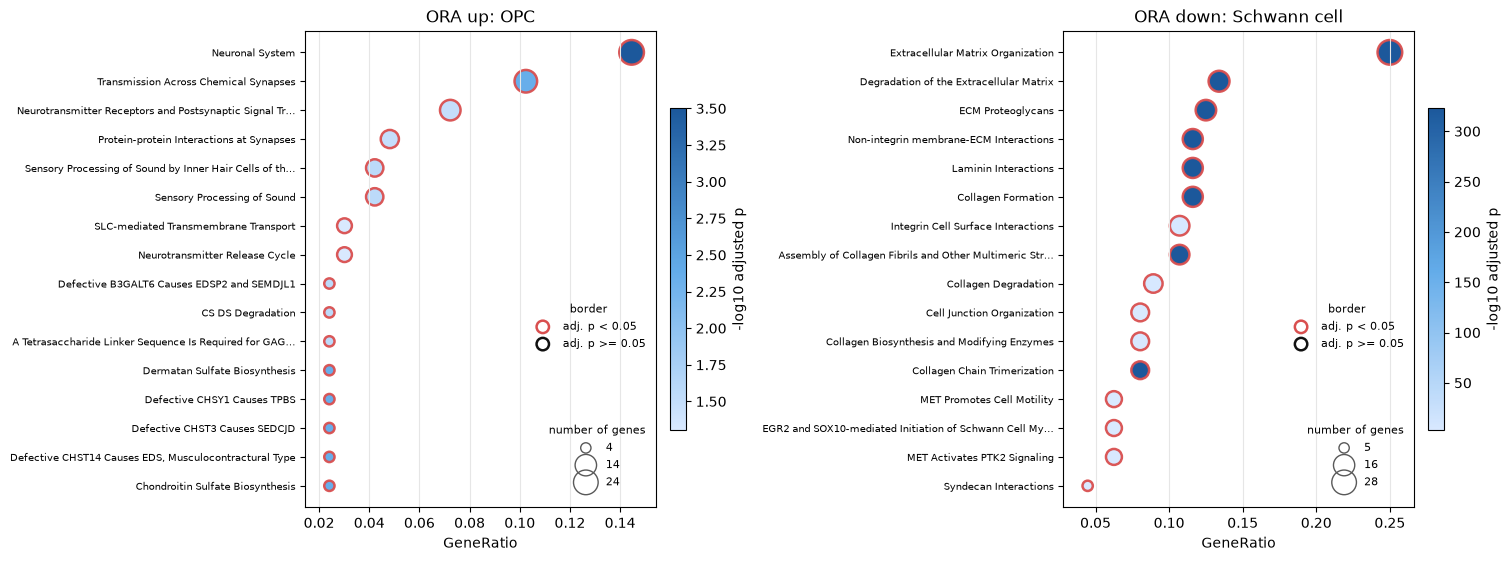

ipywidgets is unavailable; showing the first retained GSEA pathway instead.
No module named 'ipywidgets'


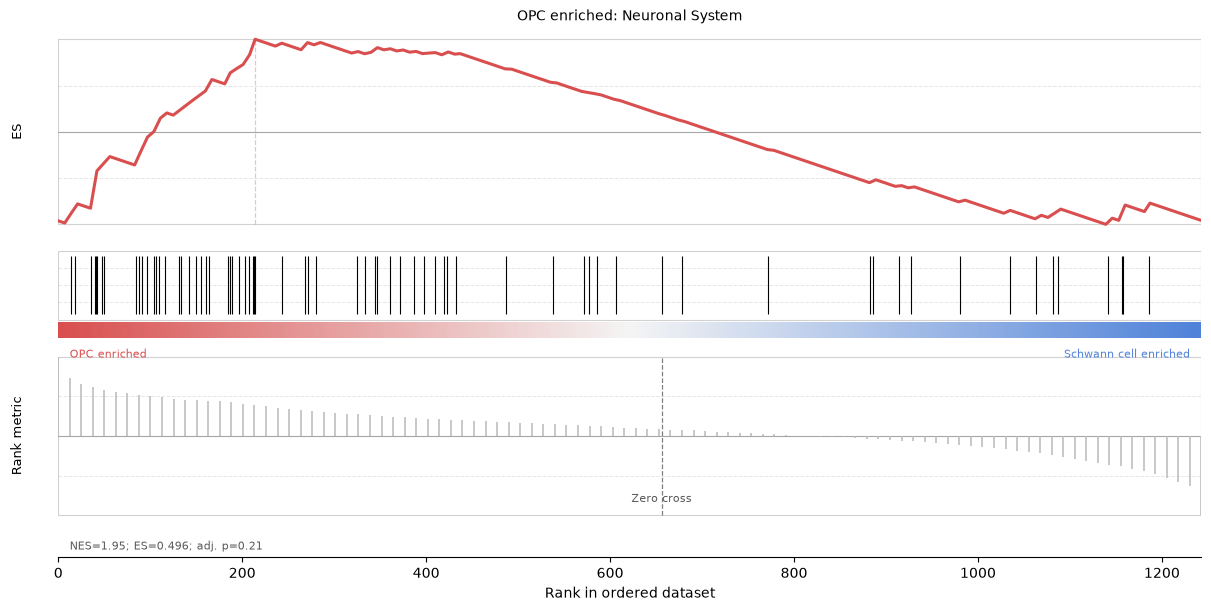

In [14]:
# Plot ORA dot plots and classic GSEA enrichment profiles, matching the viewer summaries.
from matplotlib.colors import LinearSegmentedColormap, Normalize


def _short_term(value, max_len=58):
    text = str(value or "")
    return text if len(text) <= max_len else text[: max_len - 1] + "…"


def _empty_axis(ax, title, message="No pathways"):
    ax.axis("off")
    ax.set_title(title)
    ax.text(0.5, 0.5, message, ha="center", va="center", transform=ax.transAxes)


def _score_norm(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return Normalize(vmin=0.0, vmax=1.0)
    vmin = float(np.nanmin(arr))
    vmax = float(np.nanmax(arr))
    if np.isclose(vmin, vmax):
        return Normalize(vmin=max(0.0, vmin * 0.5), vmax=vmax * 1.5 + 1e-12)
    return Normalize(vmin=vmin, vmax=vmax)


def plot_ora_dotplot(ax, df, title):
    if df is None or df.empty:
        _empty_axis(ax, title)
        return
    plot_df = df.copy()
    plot_df["overlap_n"] = pd.to_numeric(plot_df["overlap"], errors="coerce").fillna(0.0)
    plot_df["query_size_n"] = pd.to_numeric(plot_df["query_size"], errors="coerce").replace(0, np.nan)
    query_size = plot_df["query_size_n"].to_numpy(dtype=float)
    plot_df["gene_ratio"] = np.divide(
        plot_df["overlap_n"].to_numpy(dtype=float),
        query_size,
        out=np.zeros(len(plot_df), dtype=float),
        where=np.isfinite(query_size),
    )
    plot_df["padj_n"] = (
        pd.to_numeric(plot_df["padj"], errors="coerce")
        .fillna(1.0)
        .clip(np.nextafter(0.0, 1.0), 1.0)
    )
    plot_df["neg_log10_padj"] = -np.log10(plot_df["padj_n"])
    plot_df = (
        plot_df.sort_values(["gene_ratio", "padj_n", "term"], ascending=[False, True, True])
        .head(16)
        .sort_values("gene_ratio", ascending=True)
    )

    overlap = plot_df["overlap_n"].to_numpy(dtype=float)
    gene_ratio = plot_df["gene_ratio"].to_numpy(dtype=float)
    score = plot_df["neg_log10_padj"].to_numpy(dtype=float)
    size_range = max(float(np.nanmax(overlap) - np.nanmin(overlap)), 1.0)
    sizes = 55.0 + np.sqrt(np.maximum(overlap - np.nanmin(overlap), 0.0) / size_range) * 260.0
    edge_colors = np.where(plot_df["padj_n"].to_numpy(dtype=float) < 0.05, "#d94f4f", "#111111")
    y = np.arange(len(plot_df))
    blue_cmap = LinearSegmentedColormap.from_list("ora_blue", ["#d7e8ff", "#5aa7e8", "#0f4f96"])
    scatter = ax.scatter(
        gene_ratio,
        y,
        s=sizes,
        c=score,
        cmap=blue_cmap,
        norm=_score_norm(score),
        edgecolors=edge_colors,
        linewidths=1.8,
        alpha=0.95,
    )
    ax.set_yticks(y)
    ax.set_yticklabels([_short_term(term, 54) for term in plot_df["term"]], fontsize=7)
    ax.set_xlabel("GeneRatio")
    ax.set_title(title)
    ax.grid(axis="x", color="0.9", linewidth=0.8)
    ax.margins(x=0.08)
    cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("-log10 adjusted p")

    unique_sizes = np.unique(overlap.astype(int))
    handles = []
    labels = []
    if unique_sizes.size:
        legend_values = np.unique(
            np.round(np.linspace(unique_sizes.min(), unique_sizes.max(), min(3, unique_sizes.size))).astype(int)
        )
        for value in legend_values:
            radius_size = 55.0 + np.sqrt(max(value - np.nanmin(overlap), 0.0) / size_range) * 260.0
            handles.append(ax.scatter([], [], s=radius_size, facecolors="none", edgecolors="0.35"))
            labels.append(str(int(value)))
        size_legend = ax.legend(
            handles, labels, title="number of genes", loc="lower right",
            frameon=False, fontsize=8, title_fontsize=8, bbox_to_anchor=(1.0, 0.02)
        )
        ax.add_artist(size_legend)

    border_handles = [
        ax.scatter([], [], s=80, facecolors="none", edgecolors="#d94f4f", linewidths=1.8),
        ax.scatter([], [], s=80, facecolors="none", edgecolors="#111111", linewidths=1.8),
    ]
    ax.legend(
        border_handles, ["adj. p < 0.05", "adj. p >= 0.05"], title="border",
        loc="lower right", bbox_to_anchor=(1.0, 0.31), frameon=False, fontsize=8, title_fontsize=8
    )


def _to_numeric_profile(values):
    if not isinstance(values, (list, tuple)) or len(values) == 0:
        return np.empty((0, 2), dtype=float)
    arr = np.asarray(values, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 2:
        return np.empty((0, 2), dtype=float)
    return arr[:, :2]


def _scale_to_band(values, low, high, include_zero=True):
    arr = np.asarray(values, dtype=float)
    finite = arr[np.isfinite(arr)]
    if include_zero:
        finite = np.concatenate([finite, np.array([0.0])])
    if finite.size == 0:
        return np.full_like(arr, (low + high) / 2.0, dtype=float)
    vmin = float(np.nanmin(finite))
    vmax = float(np.nanmax(finite))
    if np.isclose(vmin, vmax):
        return np.full_like(arr, (low + high) / 2.0, dtype=float)
    return low + (arr - vmin) / (vmax - vmin) * (high - low)


def _fmt_number(value):
    try:
        number = float(value)
    except (TypeError, ValueError):
        return "n/a"
    return f"{number:.3g}" if np.isfinite(number) else "n/a"


def plot_gsea_enrichment(
    ax, df, title, primary_color="#d94f4f", secondary_color="#4f82d9"
):
    if df is None or df.empty:
        _empty_axis(ax, title)
        return
    row = df.iloc[0].to_dict()
    profile = _to_numeric_profile(row.get("running_profile"))
    metric = _to_numeric_profile(row.get("rank_metric_profile"))
    hits = np.asarray(row.get("hit_indices") or [], dtype=float)
    rank_count = int(row.get("rank_count") or 0)
    if profile.size == 0 or metric.size == 0 or hits.size == 0 or rank_count < 2:
        _empty_axis(ax, title, message="No GSEA profile data")
        return

    direction = str(row.get("direction", "positive"))
    direction_positive = direction != "negative"
    display_sign = 1.0 if direction_positive else -1.0
    profile_values = display_sign * profile[:, 1]
    metric_values = display_sign * metric[:, 1]
    display_profile_x = (
        profile[:, 0] if direction_positive else (rank_count - 1) - profile[:, 0]
    )
    display_metric_x = (
        metric[:, 0] if direction_positive else (rank_count - 1) - metric[:, 0]
    )
    display_hits = hits if direction_positive else (rank_count - 1) - hits
    profile_color = primary_color if direction_positive else secondary_color
    opposite_color = secondary_color if direction_positive else primary_color
    label_a = source if direction_positive else reference
    label_b = reference if direction_positive else source
    term = _short_term(row.get("term"), max_len=60)
    ax.set_title(f"{title}: {term}", fontsize=10)
    ax.set_xlim(0, rank_count - 1)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel("Rank in ordered dataset")
    for spine in ["left", "right", "top"]:
        ax.spines[spine].set_visible(False)

    es_low, es_high = 0.63, 0.98
    hit_low, hit_high = 0.45, 0.58
    metric_low, metric_high = 0.08, 0.38
    for low, high in [
        (es_low, es_high),
        (hit_low, hit_high),
        (metric_low, metric_high),
    ]:
        ax.axhspan(low, high, color="none", ec="0.82", lw=0.8)
        for frac in [0.25, 0.5, 0.75]:
            ax.axhline(
                low + (high - low) * frac, color="0.9", lw=0.7, ls="--", zorder=0
            )

    es_y = _scale_to_band(profile_values, es_low, es_high)
    zero_es = _scale_to_band(np.array([0.0]), es_low, es_high)[0]
    ax.axhline(zero_es, color="0.65", lw=0.8)
    profile_order = np.argsort(display_profile_x)
    ax.plot(
        display_profile_x[profile_order],
        es_y[profile_order],
        color=profile_color,
        lw=2.2,
        solid_joinstyle="round",
    )
    peak_rank = row.get("peak_rank")
    if pd.notna(peak_rank):
        display_peak = (
            float(peak_rank)
            if direction_positive
            else (rank_count - 1) - float(peak_rank)
        )
        ax.axvline(
            display_peak,
            ymin=es_low,
            ymax=es_high,
            color=profile_color,
            lw=0.9,
            ls="--",
            alpha=0.35,
        )

    for hit in display_hits:
        ax.vlines(hit, hit_low + 0.01, hit_high - 0.01, color="black", lw=0.8)
    cmap = LinearSegmentedColormap.from_list(
        "gsea_direction", [profile_color, "#f5f5f5", opposite_color]
    )
    ax.imshow(
        np.linspace(0, 1, 256).reshape(1, -1),
        extent=[0, rank_count - 1, hit_low - 0.035, hit_low - 0.005],
        aspect="auto",
        cmap=cmap,
        interpolation="nearest",
    )

    metric_y = _scale_to_band(metric_values, metric_low, metric_high)
    zero_metric = _scale_to_band(np.array([0.0]), metric_low, metric_high)[0]
    ax.axhline(zero_metric, color="0.65", lw=0.8)
    metric_order = np.argsort(display_metric_x)
    ax.vlines(
        display_metric_x[metric_order],
        zero_metric,
        metric_y[metric_order],
        color="0.72",
        lw=1.2,
        alpha=0.9,
    )
    zero_cross = row.get("zero_cross_rank")
    if pd.notna(zero_cross):
        display_zero = (
            float(zero_cross)
            if direction_positive
            else (rank_count - 1) - float(zero_cross)
        )
        ax.axvline(
            display_zero,
            ymin=metric_low,
            ymax=metric_high,
            color="0.5",
            lw=0.9,
            ls="--",
        )
        ax.text(
            display_zero,
            metric_low + 0.02,
            "Zero cross",
            ha="center",
            va="bottom",
            fontsize=8,
            color="0.35",
        )

    ax.text(
        -0.03,
        (es_low + es_high) / 2,
        "ES",
        ha="right",
        va="center",
        rotation=90,
        transform=ax.transAxes,
        fontsize=9,
    )
    ax.text(
        -0.03,
        (metric_low + metric_high) / 2,
        "Rank metric",
        ha="right",
        va="center",
        rotation=90,
        transform=ax.transAxes,
        fontsize=9,
    )
    ax.text(
        0.01,
        hit_low - 0.055,
        f"{label_a} enriched",
        color=profile_color,
        ha="left",
        va="top",
        transform=ax.transAxes,
        fontsize=8,
    )
    ax.text(
        0.99,
        hit_low - 0.055,
        f"{label_b} enriched",
        color=opposite_color,
        ha="right",
        va="top",
        transform=ax.transAxes,
        fontsize=8,
    )
    ax.text(
        0.01,
        0.01,
        f"NES={_fmt_number(abs(row.get('nes')))}; ES={_fmt_number(abs(row.get('es')))}; adj. p={_fmt_number(row.get('padj'))}",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=8,
        color="0.35",
    )


fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
plot_ora_dotplot(axes[0], ora_up, f"ORA up: {source}")
plot_ora_dotplot(axes[1], ora_down, f"ORA down: {reference}")
plt.show()


def _gsea_dropdown_rows():
    frames = []
    if gsea_positive is not None and not gsea_positive.empty:
        frames.append(gsea_positive.assign(gsea_direction_label=f"{source} enriched"))
    if gsea_negative is not None and not gsea_negative.empty:
        frames.append(
            gsea_negative.assign(gsea_direction_label=f"{reference} enriched")
        )
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


gsea_dropdown_df = _gsea_dropdown_rows()


def _plot_selected_gsea_pathway(row_index):
    row_index = int(row_index)
    selected = gsea_dropdown_df.iloc[[row_index]]
    fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
    direction = selected.iloc[0].get("gsea_direction_label", "GSEA")
    plot_gsea_enrichment(
        ax, selected, str(direction), primary_color="#d94f4f", secondary_color="#4f82d9"
    )
    plt.show()


if gsea_dropdown_df.empty:
    print("No GSEA pathways available for the dropdown.")
else:
    options = []
    for idx, row in gsea_dropdown_df.iterrows():
        nes = _fmt_number(abs(row.get("nes")))
        padj = _fmt_number(row.get("padj"))
        label = f"{row.get('gsea_direction_label')}: {_short_term(row.get('term'), 72)} | NES={nes}, adj. p={padj}"
        options.append((label, int(idx)))
    try:
        import ipywidgets as widgets
        from IPython.display import display

        selector = widgets.Dropdown(
            options=options, description="Pathway:", layout=widgets.Layout(width="100%")
        )
        output = widgets.interactive_output(
            _plot_selected_gsea_pathway, {"row_index": selector}
        )
        display(widgets.VBox([selector, output]))
    except Exception as exc:
        print(
            "ipywidgets is unavailable; showing the first retained GSEA pathway instead."
        )
        print(exc)
        _plot_selected_gsea_pathway(options[0][1])

In [ ]:
# Optional: save pathway tables next to the audited DE table.
# pathway_prefix = Path(H5AD_PATH).with_suffix(f".{GROUPBY}.{source}_vs_{reference}.pathway")
# for name, df in {
#     "ora_up": ora_up_table,
#     "ora_down": ora_down_table,
#     "gsea_positive": gsea_positive_table,
#     "gsea_negative": gsea_negative_table,
# }.items():
#     if df is not None and not df.empty:
#         out_path = pathway_prefix.with_suffix(f".{name}.csv")
#         df.to_csv(out_path, index=False)
#         print(out_path)